# Step 3: Econometric Analysis & Visualization
## Paper: Emergent risk asymmetry in high-dimensional multi-agent self-play
**Submission:** Nature Machine Intelligence

---

**Author:** Kenny Ching  
**Affiliation:** School of Business, University of Auckland  
**Date:** February 2026  

---

**Description:**
This notebook performs the statistical testing and generates the figures presented in the manuscript. It reproduces the "Antifragility" results by comparing the risk profiles of AI and Human agents.

**Reproducibility Targets:**
* **Table 1 & 2:** T-Tests and Segmented Regression (The "Death Offset").
* **Figure 1:** The Asymmetry of Risk Pricing (Interaction Plot).
* **Figure 2:** Distributional Shift (KDE Plot).
* **Figure 3:** Efficiency of Distressed Asset Liquidation (Bar Chart).
* **Figure 4:** Temporal Robustness (Coefficient Plot).

**Input:**
* `data/processed/tf_events_final-1.csv`

**Dependencies:**
* `statsmodels`, `seaborn`, `matplotlib`, `pandas`, `scipy`.

<>:86: SyntaxWarning: invalid escape sequence '\D'
<>:96: SyntaxWarning: invalid escape sequence '\D'
<>:86: SyntaxWarning: invalid escape sequence '\D'
<>:96: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-4282514479.py:86: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Strategic Yield (Net Worth $\Delta$ at 180s)')
/tmp/ipython-input-4282514479.py:96: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Strategic Yield (Net Worth $\Delta$ at 180s)')


Loading data from: /content/drive/My Drive/OpenAI_Data/data/tf_events_final-1.csv
Loaded 12422 events successfully.

PART 1: The Price of Life
Human Mean Yield on Death: $-2523.58
AI Mean Yield on Death:    $-772.17
Difference (AI Advantage): $1751.41

PART 2: Econometric Validation
>>> Model 1: Testing Risk Asymmetry (OLS)
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -2523.5810     45.327    -55.675      0.000   -2612.420   -2434.742
is_Kill        5085.7995     58.941     86.286      0.000    4970.277    5201.322
is_AI          1751.4143    280.495      6.244      0.000    1201.654    2301.174
is_Kill:is_AI -1626.6329   1000.258     -1.626      0.104   -3587.102     333.836

>>> Model 2: Testing Distressed Asset Efficiency (Logit)
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

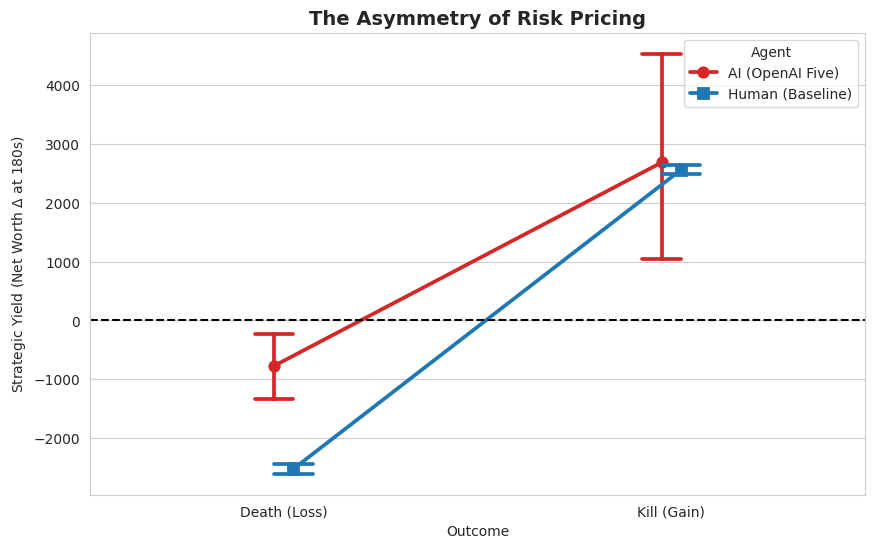

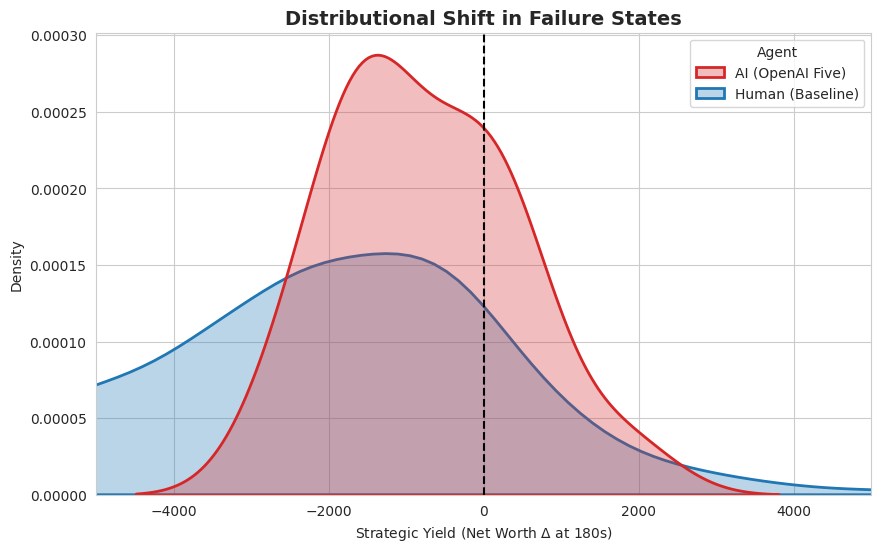

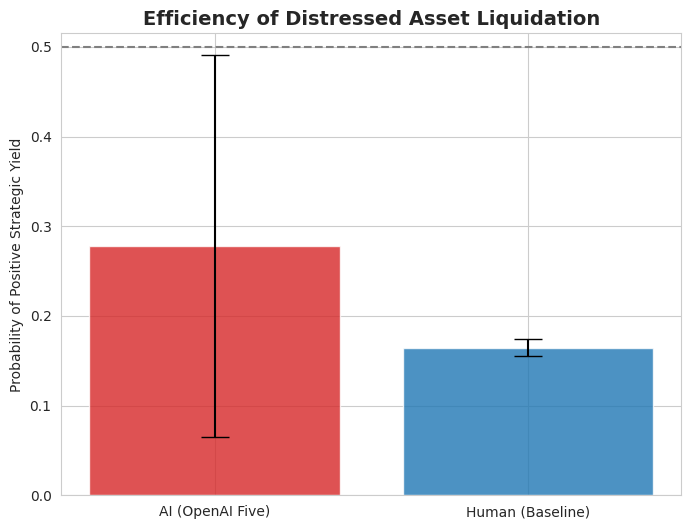

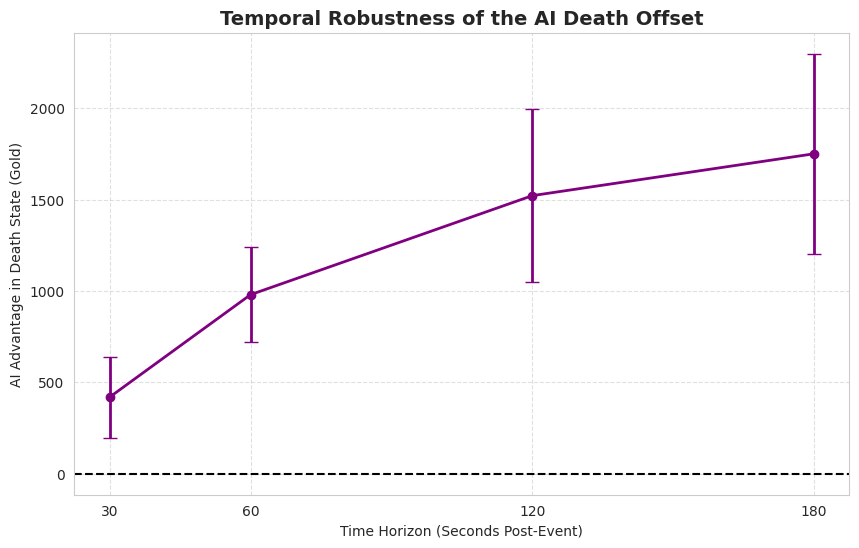

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from google.colab import drive

# --- 1. SETUP ---
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

# Point to the file we just saved in Drive
DATA_DIR = "/content/drive/My Drive/OpenAI_Data/data"
INPUT_FILE = os.path.join(DATA_DIR, "tf_events_final-1.csv")

def run_analysis():
    # 1. Load Data from Drive
    if not os.path.exists(INPUT_FILE):
        print(f"CRITICAL ERROR: File not found at {INPUT_FILE}")
        print("Did you run Script 2 and save it to Drive?")
        return

    print(f"Loading data from: {INPUT_FILE}")
    df = pd.read_csv(INPUT_FILE)
    print(f"Loaded {len(df)} events successfully.")

    # 2. Preprocessing
    # Remove draws
    df = df[df['kill_delta_radiant'] != 0].copy()

    # Create Analysis Variables
    df['Agent'] = np.where(df['is_openai5'], 'AI (OpenAI Five)', 'Human (Baseline)')
    df['Outcome'] = np.where(df['kill_delta_radiant'] > 0, 'Kill (Gain)', 'Death (Loss)')
    df['is_AI'] = df['is_openai5'].astype(int)
    df['is_Kill'] = (df['kill_delta_radiant'] > 0).astype(int)

    # --- PART A: STATISTICS ---
    print("\n" + "="*40)
    print("PART 1: The Price of Life")
    print("="*40)

    # Calculate means
    ai_death_yield = df[(df['is_AI']==1) & (df['is_Kill']==0)]['gadv_d180'].mean()
    hu_death_yield = df[(df['is_AI']==0) & (df['is_Kill']==0)]['gadv_d180'].mean()

    print(f"Human Mean Yield on Death: ${hu_death_yield:.2f}")
    print(f"AI Mean Yield on Death:    ${ai_death_yield:.2f}")
    print(f"Difference (AI Advantage): ${ai_death_yield - hu_death_yield:.2f}")

    # --- PART B: REGRESSIONS ---
    print("\n" + "="*40)
    print("PART 2: Econometric Validation")
    print("="*40)

    # Model 1: Antifragility (Linear)
    print(">>> Model 1: Testing Risk Asymmetry (OLS)")
    model1 = smf.ols("gadv_d180 ~ is_Kill + is_AI + is_Kill:is_AI", data=df).fit(cov_type='cluster', cov_kwds={'groups': df['match_id']})
    print(model1.summary().tables[1])

    # Model 2: Efficiency (Logistic)
    print("\n>>> Model 2: Testing Distressed Asset Efficiency (Logit)")
    df_deaths = df[df['Outcome'] == 'Death (Loss)'].copy()
    df_deaths['Success'] = (df_deaths['gadv_d180'] > 0).astype(int)

    model2 = smf.logit("Success ~ is_AI", data=df_deaths).fit(disp=0)
    print(model2.summary().tables[1])
    print(f"Odds Ratio: {np.exp(model2.params['is_AI']):.4f}")

    # --- PART C: PLOTS ---
    print("\n" + "="*40)
    print("PART 3: Generating Figures")
    print("="*40)

    sns.set_style("whitegrid")
    palette = {'AI (OpenAI Five)': '#d62728', 'Human (Baseline)': '#1f77b4'}

    # Figure 1: Asymmetry
    plt.figure(figsize=(10, 6))
    sns.pointplot(x='Outcome', y='gadv_d180', hue='Agent', data=df,
                  dodge=True, markers=['o', 's'], capsize=.1, errorbar=('ci', 95),
                  palette=palette)
    plt.title('The Asymmetry of Risk Pricing', fontsize=14, weight='bold')
    plt.ylabel('Strategic Yield (Net Worth $\Delta$ at 180s)')
    plt.axhline(0, color='black', ls='--')
    plt.savefig('fig1_asymmetry.png', dpi=300)
    print("Saved fig1_asymmetry.png")

    # Figure 2: Distribution
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_deaths, x='gadv_d180', hue='Agent', fill=True, common_norm=False,
                palette=palette, alpha=0.3, linewidth=2)
    plt.title('Distributional Shift in Failure States', fontsize=14, weight='bold')
    plt.xlabel('Strategic Yield (Net Worth $\Delta$ at 180s)')
    plt.xlim(-5000, 5000)
    plt.axvline(0, color='black', ls='--')
    plt.savefig('fig2_distribution.png', dpi=300)
    print("Saved fig2_distribution.png")

    # Figure 3: Efficiency
    eff = df_deaths.groupby('Agent')['Success'].agg(['mean', 'sem']).reset_index()
    plt.figure(figsize=(8, 6))
    plt.bar(eff['Agent'], eff['mean'], yerr=eff['sem']*1.96, capsize=10,
            color=[palette[a] for a in eff['Agent']], alpha=0.8)
    plt.title('Efficiency of Distressed Asset Liquidation', fontsize=14, weight='bold')
    plt.ylabel('Probability of Positive Strategic Yield')
    plt.axhline(0.5, color='gray', ls='--')
    plt.savefig('fig3_efficiency.png', dpi=300)
    print("Saved fig3_efficiency.png")

    # Figure 4: Robustness
    horizons = [30, 60, 120, 180]
    res = []
    for h in horizons:
        col = f'gadv_d{h}'
        ai = df[(df['is_AI']==1) & (df['is_Kill']==0)][col]
        hu = df[(df['is_AI']==0) & (df['is_Kill']==0)][col]
        res.append({'H': h, 'Off': ai.mean() - hu.mean(), 'SE': np.sqrt(ai.sem()**2 + hu.sem()**2)})

    rdf = pd.DataFrame(res)
    plt.figure(figsize=(10, 6))
    plt.errorbar(rdf['H'], rdf['Off'], yerr=rdf['SE']*1.96, fmt='-o', color='purple', capsize=5, linewidth=2)
    plt.title('Temporal Robustness of the AI Death Offset', fontsize=14, weight='bold')
    plt.xlabel('Time Horizon (Seconds Post-Event)')
    plt.ylabel('AI Advantage in Death State (Gold)')
    plt.axhline(0, color='black', ls='--')
    plt.xticks(horizons)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('fig4_horizon.png', dpi=300)
    print("Saved fig4_horizon.png")

if __name__ == "__main__":
    run_analysis()